# LVP-Net: Lateral Visual Pathway Network

**Bio-Inspired Deep Learning Model**

Paper: "Hierarchical visual pathway simulation with feedback refinement"

This notebook:
- Implements LVP-Net architecture
- Tests on HED_Small dataset
- Computes ODS/OIS/AP metrics
- Visualizes results

**Bio-Inspiration**: Hierarchical visual pathway with feedback refinement  
**Improvement Area**: Edge continuity and suppression of noise

In [1]:
# ===== Configuration =====
from pathlib import Path
import sys

PROJECT_ROOT = Path('..')
DATASET_ROOT = PROJECT_ROOT / 'datasets' / 'HED_Small'
MODELS_DIR = PROJECT_ROOT / 'models' / 'lvp_net'
OUTPUT_DIR = PROJECT_ROOT / 'bio DL' / 'outputs' / 'LVP-Net'

DEVICE = 'cuda'
BATCH_SIZE = 1
NUM_TEST_IMAGES = 20

In [2]:
# ===== Installs and Imports =====
import subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch', 'torchvision', 'opencv-python', 'matplotlib', 'numpy', 'pillow', 'tqdm', 'scikit-learn'], check=False)

import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import average_precision_score

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## LVP-Net Architecture

LVP-Net implements hierarchical visual pathway processing with feedback:
- **Bottom-up pathway**: V1 → V2 → V4 feature extraction
- **Top-down feedback**: Refines lower-level representations
- **Lateral connections**: Facilitates feature integration

In [3]:
# ===== LVP-Net Architecture =====
class LateralConnection(nn.Module):
    """Lateral connections between processing stages"""
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn = nn.BatchNorm2d(channels)
        
    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))

class FeedbackRefinement(nn.Module):
    """Top-down feedback refinement module"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.refine = nn.Sequential(
            nn.Conv2d(out_ch * 2, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
        
    def forward(self, high_level, low_level):
        up = self.upsample(high_level)
        combined = torch.cat([up, low_level], dim=1)
        return self.refine(combined)

class LVPNet(nn.Module):
    """Lateral Visual Pathway Network"""
    
    def __init__(self):
        super(LVPNet, self).__init__()
        
        # Bottom-up pathway (V1-like → V2-like → V4-like)
        # V1 stage (low-level features)
        self.v1_conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.v1_conv2 = nn.Conv2d(64, 64, 3, padding=1)
        self.v1_lateral = LateralConnection(64)
        
        # V2 stage (intermediate features)
        self.v2_conv1 = nn.Conv2d(64, 128, 3, padding=1)
        self.v2_conv2 = nn.Conv2d(128, 128, 3, padding=1)
        self.v2_lateral = LateralConnection(128)
        
        # V4 stage (high-level features)
        self.v4_conv1 = nn.Conv2d(128, 256, 3, padding=1)
        self.v4_conv2 = nn.Conv2d(256, 256, 3, padding=1)
        self.v4_lateral = LateralConnection(256)
        
        # Top-down feedback refinement
        self.feedback_v4_v2 = FeedbackRefinement(256, 128)
        self.feedback_v2_v1 = FeedbackRefinement(128, 64)
        
        # Edge prediction layers
        self.edge_v1 = nn.Conv2d(64, 1, 1)
        self.edge_v2 = nn.Conv2d(128, 1, 1)
        self.edge_v4 = nn.Conv2d(256, 1, 1)
        
        # Final fusion
        self.fusion = nn.Conv2d(3, 1, 1)
        
    def forward(self, x):
        h, w = x.shape[2:]
        
        # Bottom-up pathway
        # V1 processing
        v1 = F.relu(self.v1_conv1(x))
        v1 = F.relu(self.v1_conv2(v1))
        v1 = v1 + self.v1_lateral(v1)  # Lateral connection
        pool1 = F.max_pool2d(v1, 2)
        
        # V2 processing
        v2 = F.relu(self.v2_conv1(pool1))
        v2 = F.relu(self.v2_conv2(v2))
        v2 = v2 + self.v2_lateral(v2)  # Lateral connection
        pool2 = F.max_pool2d(v2, 2)
        
        # V4 processing
        v4 = F.relu(self.v4_conv1(pool2))
        v4 = F.relu(self.v4_conv2(v4))
        v4 = v4 + self.v4_lateral(v4)  # Lateral connection
        
        # Top-down feedback refinement
        v2_refined = self.feedback_v4_v2(v4, v2)
        v1_refined = self.feedback_v2_v1(v2_refined, v1)
        
        # Generate edge maps from refined features
        edge_v1 = self.edge_v1(v1_refined)
        edge_v2 = self.edge_v2(v2_refined)
        edge_v4 = self.edge_v4(v4)
        
        # Upsample to original size
        edge_v1 = F.interpolate(edge_v1, (h, w), mode='bilinear', align_corners=False)
        edge_v2 = F.interpolate(edge_v2, (h, w), mode='bilinear', align_corners=False)
        edge_v4 = F.interpolate(edge_v4, (h, w), mode='bilinear', align_corners=False)
        
        # Fuse all edge maps
        fused = self.fusion(torch.cat([edge_v1, edge_v2, edge_v4], dim=1))
        
        return torch.sigmoid(fused), [torch.sigmoid(e) for e in [edge_v1, edge_v2, edge_v4]]

model = LVPNet().to(DEVICE)
print(f"✓ Created LVP-Net model")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Created LVP-Net model
Model parameters: 2,454,599


## Search for Pretrained Weights

In [4]:
# ===== Search for Pretrained Weights =====
def find_pretrained_model():
    search_paths = [
        MODELS_DIR / 'lvpnet_pretrained.pth',
        PROJECT_ROOT / 'models' / 'lvpnet.pth',
    ]
    
    for path in search_paths:
        if path.exists():
            return path
    
    # Search recursively
    model_files = list(PROJECT_ROOT.rglob('*lvp*.pth'))
    if model_files:
        return model_files[0]
    
    return None

model_path = find_pretrained_model()

if model_path:
    print(f"Found pretrained model: {model_path}")
    try:
        state_dict = torch.load(model_path, map_location=DEVICE)
        if isinstance(state_dict, dict) and 'model' in state_dict:
            state_dict = state_dict['model']
        elif isinstance(state_dict, dict) and 'state_dict' in state_dict:
            state_dict = state_dict['state_dict']
        model.load_state_dict(state_dict, strict=False)
        print("✓ Loaded pretrained weights")
    except Exception as e:
        print(f"⚠ Could not load weights: {e}")
        print("Using random initialization (results will be poor without training)")
else:
    print("⚠ No pretrained model found")
    print("Using random initialization (results will be poor without training)")

model.eval()

⚠ No pretrained model found
Using random initialization (results will be poor without training)


LVPNet(
  (v1_conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (v1_conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (v1_lateral): LateralConnection(
    (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (v2_conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (v2_conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (v2_lateral): LateralConnection(
    (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (v4_conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (v4_conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (v4_lateral): LateralConnection(
    (conv): Conv2d(256, 256, kernel_size=(3, 3), strid

## Dataset and Evaluation

In [5]:
# ===== Dataset =====
class EdgeDataset(Dataset):
    def __init__(self, root, split='test'):
        self.img_dir = root / split / 'images'
        self.gt_dir = root / split / 'edges'
        self.images = sorted(list(self.img_dir.glob('*.jpg')) + list(self.img_dir.glob('*.png')))
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        gt_path = self.gt_dir / img_path.name.replace('.jpg', '.png')
        
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        if gt_path.exists():
            gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        else:
            gt = np.zeros((h, w), dtype=np.float32)
        
        img = img.astype(np.float32) / 255.0
        img = img.transpose(2, 0, 1)
        
        return torch.from_numpy(img), torch.from_numpy(gt), img_path.name

test_dataset = EdgeDataset(DATASET_ROOT, 'test')
if NUM_TEST_IMAGES:
    test_dataset.images = test_dataset.images[:NUM_TEST_IMAGES]
    
print(f"Test images: {len(test_dataset)}")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Test images: 20


In [6]:
# ===== Evaluation Metrics =====
def dilate_gt(gt, r=1):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1))
    return cv2.dilate(gt, kernel)

def compute_ods_ois_ap(preds, labels, thresholds=30):
    threshs = np.linspace(0.05, 0.95, thresholds)
    all_preds, all_labels, ois_f1_scores = [], [], []
    
    for pred, label in zip(preds, labels):
        label_binary = (label > 0.5).astype(np.float32)
        label_tol = dilate_gt(label_binary, r=1).flatten()
        pred_smooth = cv2.GaussianBlur(pred, (3,3), 0).flatten()
        
        all_preds.append(pred_smooth)
        all_labels.append(label_tol)
        
        best_f1 = 0.0
        for t in threshs:
            pred_bin = (pred_smooth >= t).astype(np.float32)
            tp = np.sum(pred_bin * label_tol)
            fp = np.sum(pred_bin * (1 - label_tol))
            fn = np.sum((1 - pred_bin) * label_tol)
            
            precision = tp / (tp + fp + 1e-8)
            recall = tp / (tp + fn + 1e-8)
            f1 = 2 * precision * recall / (precision + recall + 1e-8)
            best_f1 = max(best_f1, f1)
        
        ois_f1_scores.append(best_f1)
    
    ois = np.mean(ois_f1_scores)
    all_preds_flat = np.concatenate(all_preds)
    all_labels_flat = np.concatenate(all_labels)
    
    best_ods, best_thresh = 0.0, 0.0
    for t in threshs:
        pred_bin = (all_preds_flat >= t).astype(np.float32)
        tp = np.sum(pred_bin * all_labels_flat)
        fp = np.sum(pred_bin * (1 - all_labels_flat))
        fn = np.sum((1 - pred_bin) * all_labels_flat)
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        
        if f1 > best_ods:
            best_ods, best_thresh = f1, t
    
    try:
        ap = average_precision_score(all_labels_flat, all_preds_flat)
    except:
        ap = 0.0
    
    return {'ODS': best_ods, 'ODS_thresh': best_thresh, 'OIS': ois, 'AP': ap}

## Inference and Results

In [7]:
# ===== Run Inference =====
predictions, ground_truths, image_names = [], [], []

print("Running inference...")
with torch.no_grad():
    for imgs, gts, names in tqdm(test_loader):
        imgs = imgs.to(DEVICE)
        fuse, sides = model(imgs)
        
        for i in range(fuse.shape[0]):
            pred = fuse[i, 0].cpu().numpy()
            gt = gts[i].cpu().numpy()
            predictions.append(pred)
            ground_truths.append(gt)
            image_names.append(names[i])

print(f"✓ Processed {len(predictions)} images")

# Compute metrics
metrics = compute_ods_ois_ap(predictions, ground_truths)

print("\n" + "="*60)
print("LVP-Net - Bio-Inspired DL Results")
print("="*60)
print(f"ODS: {metrics['ODS']:.4f} @ threshold {metrics['ODS_thresh']:.3f}")
print(f"OIS: {metrics['OIS']:.4f}")
print(f"AP:  {metrics['AP']:.4f}")
print("="*60)

Running inference...


  0%|          | 0/20 [00:00<?, ?it/s]

✓ Processed 20 images

LVP-Net - Bio-Inspired DL Results
ODS: 0.0160 @ threshold 0.050
OIS: 0.0159
AP:  0.0077


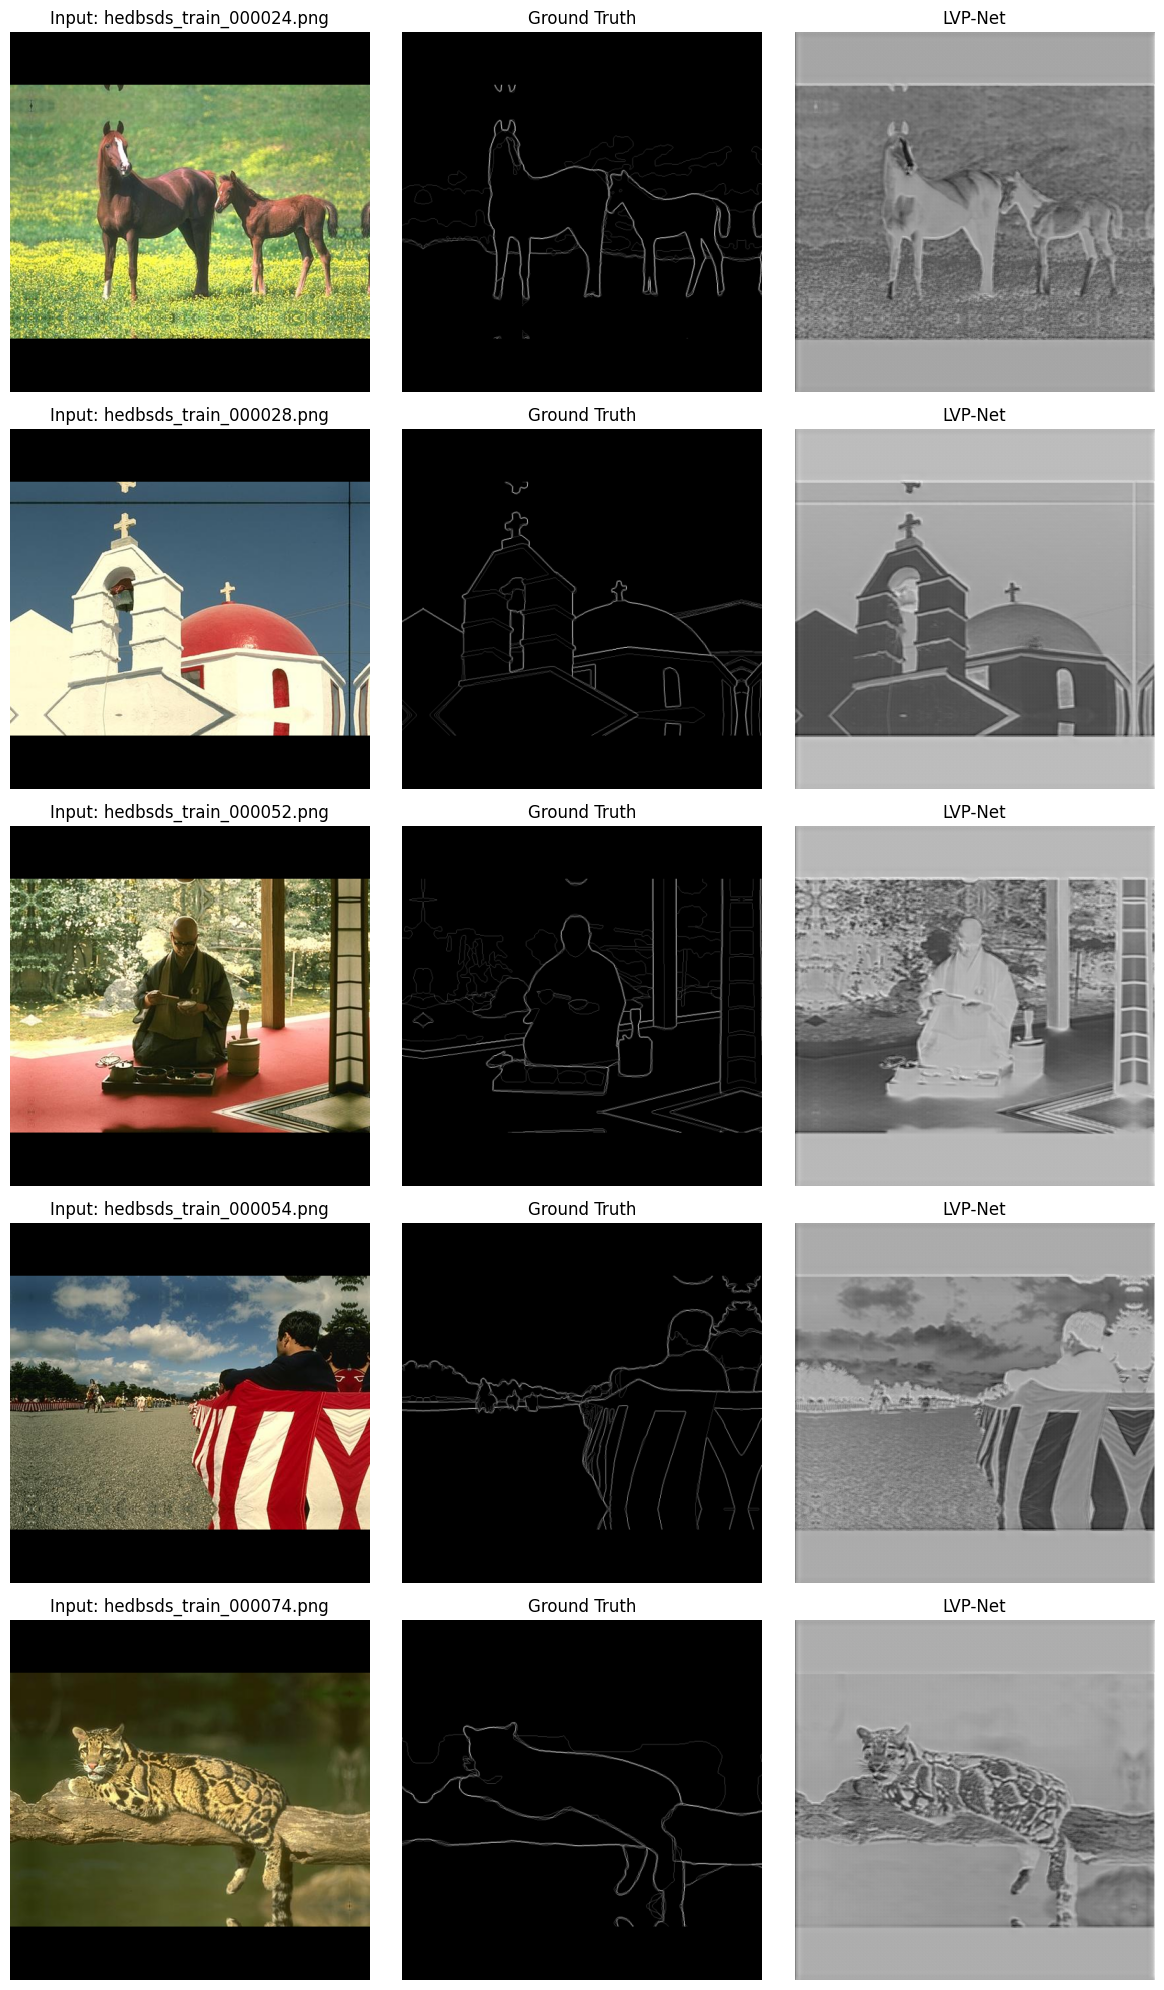

In [8]:
# ===== Visualize =====
num_viz = min(5, len(predictions))
fig, axes = plt.subplots(num_viz, 3, figsize=(12, 4*num_viz))
if num_viz == 1:
    axes = axes.reshape(1, -1)

for i in range(num_viz):
    img_path = DATASET_ROOT / 'test' / 'images' / image_names[i]
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Input: {image_names[i]}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(ground_truths[i], cmap='gray')
    axes[i, 1].set_title('Ground Truth')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(predictions[i], cmap='gray')
    axes[i, 2].set_title('LVP-Net')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lvpnet_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ===== Save Results =====
import json

results = {
    'model': 'LVP-Net',
    'paper': 'Hierarchical visual pathway simulation',
    'bio_inspired': True,
    'bio_mechanism': 'Feedback refinement in visual hierarchy',
    'improvement_area': 'Edge continuity and suppression of noise',
    'metrics': metrics,
    'num_test_images': len(predictions),
    'device': str(DEVICE)
}

with open(OUTPUT_DIR / 'lvpnet_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"✓ Saved to {OUTPUT_DIR}")
print("\n✅ LVP-Net evaluation complete!")

TypeError: Object of type float32 is not JSON serializable